# 03_evaluate – All Agents vs Baselines

Load tất cả agents đã train (pkl), evaluate công bằng trên test stream.

**Flow:**
1. Setup
2. Load data & warm-up (tất cả agents dùng chung 1 clf_warmed)
3. Evaluate baselines (Static, Periodic, Always)
4. Evaluate MC Agent
5. Evaluate 4 TD Agents
6. Summary table
7. Visualizations


In [1]:
!git clone https://github.com/Briannguyen3106/RL-concept-drift.git
%cd RL-concept-drift
!pip install -r requirements.txt

Cloning into 'RL-concept-drift'...
remote: Enumerating objects: 161, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 161 (delta 59), reused 142 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (161/161), 11.90 MiB | 17.39 MiB/s, done.
Resolving deltas: 100% (59/59), done.
/kaggle/working/RL-concept-drift


## 1. Setup

In [2]:
import sys, os
import numpy as np
import pandas as pd
import copy
from collections import deque

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from config import (
    BATCH_SIZE, CATEGORICAL_COLS,
    FULL_WINDOW_BATCHES, PARTIAL_WINDOW_BATCHES,
)
from utils.data_loader import AirlinesDataLoader
from models.LightGBM import LightGBM
from metrics.stream_metrics import StreamMetrics
from environment.drift_env import DriftStreamEnv, ACTIONS
from agents.mc_agent import MCAgent
from agents.td_agent import SARSAAgent, ExpectedSARSAAgent, QLearningAgent, DoubleQLearningAgent
from utils.visualizer import (
    plot_cumulative_reward,
    plot_action_distribution,
    plot_agent_vs_baselines,
    plot_retrain_events,
    plot_dashboard,
)

SAVE_DIR = os.path.join(PROJECT_ROOT, 'RL-concept-drift', 'experiments', 'saved_models')
print('Setup complete!')

Setup complete!


## 2. Load Data

In [3]:
loader = AirlinesDataLoader()

print(f'Train stream : {loader.n_train_batches} batches')
print(f'Test  stream : {loader.n_test_batches} batches')
print(f'Warm-up      : {FULL_WINDOW_BATCHES} batches cuối train stream')

[DataLoader] Loading data from: /kaggle/working/RL-concept-drift/data/Airlines.csv
[DataLoader] Raw shape: (539383, 9)
[DataLoader] 'Airline' → category dtype (18 unique values)
[DataLoader] 'AirportFrom' → category dtype (293 unique values)
[DataLoader] 'AirportTo' → category dtype (293 unique values)
[DataLoader] Initial train size : 20,000
[DataLoader] Stream size        : 519,383
[DataLoader] Class distribution (train) – 0: 11,529 | 1: 8,471
[DataLoader] Stream split → Train: 363 batches | Test: 156 batches
Train stream : 363 batches
Test  stream : 156 batches
Warm-up      : 10 batches cuối train stream


## 3. Warm-up

Tất cả agents và baselines bắt đầu test stream với **cùng một warm-up model**:
- `LightGBM.full_retrain(X_warm)` trên `FULL_WINDOW_BATCHES` batches cuối train stream
- Không train trên `X_train` trước – tránh model nhớ data cũ từ đầu stream
- `deepcopy` trong `env.reset(warm_model=...)` đảm bảo agents không ảnh hưởng lẫn nhau


In [4]:
X_warm, y_warm = loader.get_warmup_data(n_batches=FULL_WINDOW_BATCHES)
print(f'Warm-up data : {X_warm.shape} '
      f'({FULL_WINDOW_BATCHES} batches × {BATCH_SIZE} = {len(X_warm):,} samples)')

def warmup_clf(name: str) -> LightGBM:
    """Fresh clf trained ONLY on X_warm – không dùng X_train."""
    warmed = LightGBM()
    warmed.full_retrain(X_warm, y_warm)
    print(f'  [{name}] Warmed up on {len(X_warm):,} samples')
    return warmed

print('\nWarming up...')
clf_static        = warmup_clf('Static')
clf_periodic      = warmup_clf('Periodic')
clf_always        = warmup_clf('Always')
clf_warmed_agents = warmup_clf('All Agents (MC + TD)')   # dùng chung cho tất cả agents

print('\nAll models warmed up!')

Warm-up data : (10000, 7) (10 batches × 1000 = 10,000 samples)

Warming up...
  [Static] Warmed up on 10,000 samples
  [Periodic] Warmed up on 10,000 samples
  [Always] Warmed up on 10,000 samples
  [All Agents (MC + TD)] Warmed up on 10,000 samples

All models warmed up!


## 4. Load Agents

In [5]:
def load_agent(cls, filename):
    path = os.path.join(SAVE_DIR, filename)
    agent = cls.load(path)
    return agent

agent_mc    = load_agent(MCAgent,              'mc_agent.pkl')
agent_sarsa = load_agent(SARSAAgent,           'td/sarsa.pkl')
agent_exp   = load_agent(ExpectedSARSAAgent,   'td/expected_sarsa.pkl')
agent_ql    = load_agent(QLearningAgent,       'td/qlearning.pkl')
agent_dql   = load_agent(DoubleQLearningAgent, 'td/double_qlearning.pkl')

agents = {
    'MC Agent'          : agent_mc,
    'SARSA'             : agent_sarsa,
    'Expected SARSA'    : agent_exp,
    'Q-Learning'        : agent_ql,
    'Double Q-Learning' : agent_dql,
}

print('\nLoaded agents:')
for name, agent in agents.items():
    n_states = len(agent.Q)
    eps      = getattr(agent, 'epsilon', 'N/A')
    print(f'  {name:<22} | States: {n_states:>5} | Epsilon: {eps}')

[MCAgent] Loaded | Episodes: 200 | States: 127
[SARSAAgent] Loaded | Episodes: 4000 | States: 257
[ExpectedSARSAAgent] Loaded | Episodes: 4000 | States: 260
[QLearningAgent] Loaded | Episodes: 4000 | States: 257
[DoubleQLearningAgent] Loaded | Episodes: 4000 | States: 320

Loaded agents:
  MC Agent               | States:   127 | Epsilon: N/A
  SARSA                  | States:   257 | Epsilon: 0.3
  Expected SARSA         | States:   260 | Epsilon: 0.3
  Q-Learning             | States:   257 | Epsilon: 0.3
  Double Q-Learning      | States:   320 | Epsilon: 0.3


## 5. Setup Environment

In [6]:
clf     = LightGBM()
metrics = StreamMetrics()
env     = DriftStreamEnv(loader, clf, metrics)
print('Environment ready.')

Environment ready.


## 6. Helper Functions

In [7]:
def evaluate_agent(agent, label: str, n_episodes: int = 3) -> dict:
    """
    Prequential evaluation trên test stream.
    - warm_model = clf_warmed_agents (deepcopy mỗi lần reset)
    - TD agents: epsilon = 0.0 khi evaluate → pure greedy
    - n_episodes > 1 để average qua stochasticity
    """
    print(f'\n=== Evaluating {label} ({n_episodes} episodes) ===')

    # TD agents: set epsilon = 0.0 → pure greedy
    original_epsilon = getattr(agent, 'epsilon', None)
    if original_epsilon is not None:
        agent.epsilon = 0.0
        print(f'  Epsilon → 0.0 (pure greedy)')

    all_preq_acc    = []
    all_rolling_err = []
    all_drift       = []
    all_uncertainty = []
    all_rewards     = []
    all_actions     = []
    all_retrains    = []

    for ep in range(n_episodes):
        state     = env.reset(start_batch=0, mode='test', warm_model=clf_warmed_agents)
        env.metrics.reset()
        ep_reward = 0.0
        ep_actions  = []
        ep_retrains = []

        while not env.is_done:
            result = agent.select_action(state)
            if isinstance(result, tuple):
                action, pi = result
            else:
                action, pi = result, None

            next_state, reward, done, info = env.step(
                action,
                current_state   = state,
                pi              = pi,
                update_explorer = False,
            )

            if done and 'action_taken' not in info:
                break

            ep_reward += reward
            ep_actions.append(info['action_taken'])
            if info['action_taken'] in ('partial_update', 'full_retrain'):
                ep_retrains.append(info['batch_idx'])

            state = next_state

        all_rewards.append(ep_reward)
        all_actions.append(ep_actions)
        all_retrains.append(ep_retrains)
        all_preq_acc.append(list(env.metrics.prequential_acc_history))
        all_rolling_err.append(list(env.metrics.rolling_error_history))
        all_drift.append(list(env.metrics.drift_measure_history))
        all_uncertainty.append(list(env.metrics.uncertainty_history))
        print(f'  Ep {ep+1}: reward={ep_reward:.2f} | steps={len(ep_actions)} | retrains={len(ep_retrains)}')

    # Restore epsilon
    if original_epsilon is not None:
        agent.epsilon = original_epsilon

    # Average qua episodes
    min_len         = min(len(h) for h in all_preq_acc)
    avg_preq_acc    = np.mean([h[:min_len] for h in all_preq_acc],    axis=0).tolist()
    avg_rolling_err = np.mean([h[:min_len] for h in all_rolling_err], axis=0).tolist()
    avg_drift       = np.mean([h[:min_len] for h in all_drift],       axis=0).tolist()
    avg_uncertainty = np.mean([h[:min_len] for h in all_uncertainty], axis=0).tolist()

    action_dist = {}
    for ep_act in all_actions:
        for a in ep_act:
            action_dist[a] = action_dist.get(a, 0) + 1
    total_acts = sum(action_dist.values())
    action_dist_pct = {k: round(100*v/total_acts, 1) for k, v in action_dist.items()}

    avg_retrains = np.mean([len(r) for r in all_retrains])

    print(f'  Avg reward     : {np.mean(all_rewards):.4f} ± {np.std(all_rewards):.4f}')
    print(f'  Final preq acc : {avg_preq_acc[-1]:.4f}')
    print(f'  Avg retrains   : {avg_retrains:.1f}')
    print(f'  Action dist    : {action_dist_pct}')

    return {
        'label'          : label,
        'prequential_acc': avg_preq_acc,
        'rolling_error'  : avg_rolling_err,
        'drift_measure'  : avg_drift,
        'uncertainty'    : avg_uncertainty,
        'episode_rewards': all_rewards,
        'action_dist'    : action_dist,
        'action_dist_pct': action_dist_pct,
        'retrain_events' : all_retrains[-1],
        'avg_retrains'   : avg_retrains,
        'final_summary'  : {
            'prequential_accuracy': avg_preq_acc[-1],
            'rolling_error'       : avg_rolling_err[-1],
            'avg_reward'          : float(np.mean(all_rewards)),
        },
    }


def run_baseline(strategy: str, clf_warmed: LightGBM, retrain_every: int = 50) -> dict:
    """Baseline evaluation trên test stream với prequential order đúng."""
    print(f'\n=== Baseline: {strategy.upper()} ===')

    clf           = copy.deepcopy(clf_warmed)
    metrics_bl    = StreamMetrics()
    window_buffer = deque(maxlen=FULL_WINDOW_BATCHES)

    # Set reference từ warm-up data
    fold_size   = max(len(X_warm) // 5, 1)
    init_errors = [
        clf.get_error_rate(
            X_warm.iloc[i*fold_size:(i+1)*fold_size],
            y_warm.iloc[i*fold_size:(i+1)*fold_size]
        ) for i in range(5)
    ]
    metrics_bl.set_reference(init_errors)

    retrain_events = []
    batch_count    = 0

    for X_batch, y_batch, idx in loader.stream_test_batches():
        window_buffer.append((X_batch, y_batch))

        # Prequential: predict TRƯỚC retrain
        preds      = clf.predict(X_batch)
        y_proba    = clf.predict_proba(X_batch)
        error_rate = clf.get_error_rate(X_batch, y_batch)
        metrics_bl.update(y_batch.values, preds, error_rate, y_proba)

        if strategy == 'periodic' and batch_count > 0 and batch_count % retrain_every == 0:
            X_w = pd.concat([b[0] for b in window_buffer], ignore_index=True)
            y_w = pd.concat([b[1] for b in window_buffer], ignore_index=True)
            for col in CATEGORICAL_COLS:
                X_w[col] = X_w[col].astype('category')
            clf.full_retrain(X_w, y_w)
            retrain_events.append(idx)

        elif strategy == 'always':
            X_w = pd.concat([b[0] for b in window_buffer], ignore_index=True)
            y_w = pd.concat([b[1] for b in window_buffer], ignore_index=True)
            for col in CATEGORICAL_COLS:
                X_w[col] = X_w[col].astype('category')
            clf.full_retrain(X_w, y_w)
            retrain_events.append(idx)

        batch_count += 1

    print(f'  Done! Batches: {batch_count} | Retrains: {len(retrain_events)}')
    return {
        'label'          : strategy,
        'prequential_acc': list(metrics_bl.prequential_acc_history),
        'rolling_error'  : list(metrics_bl.rolling_error_history),
        'drift_measure'  : list(metrics_bl.drift_measure_history),
        'uncertainty'    : list(metrics_bl.uncertainty_history),
        'retrain_events' : retrain_events,
        'avg_retrains'   : len(retrain_events),
        'action_dist'    : {},
        'action_dist_pct': {},
        'final_summary'  : {
            'prequential_accuracy': metrics_bl.prequential_acc_history[-1],
            'rolling_error'       : metrics_bl.rolling_error_history[-1],
            'avg_reward'          : float('nan'),
        },
    }

## 7. Evaluate Baselines

In [8]:
results_static   = run_baseline('static',   clf_static)
results_periodic = run_baseline('periodic', clf_periodic, retrain_every=50)
results_always   = run_baseline('always',   clf_always)


=== Baseline: STATIC ===
  Done! Batches: 156 | Retrains: 0

=== Baseline: PERIODIC ===
  Done! Batches: 156 | Retrains: 3

=== Baseline: ALWAYS ===
  Done! Batches: 156 | Retrains: 156


## 8. Evaluate Agents

In [9]:
N_EVAL_EPISODES = 3

results_mc  = evaluate_agent(agent_mc,    'MC Agent',          n_episodes=N_EVAL_EPISODES)
results_sarsa = evaluate_agent(agent_sarsa, 'SARSA',           n_episodes=N_EVAL_EPISODES)
results_exp   = evaluate_agent(agent_exp,   'Expected SARSA',  n_episodes=N_EVAL_EPISODES)
results_ql    = evaluate_agent(agent_ql,    'Q-Learning',      n_episodes=N_EVAL_EPISODES)
results_dql   = evaluate_agent(agent_dql,   'Double Q-Learning', n_episodes=N_EVAL_EPISODES)


=== Evaluating MC Agent (3 episodes) ===
  Ep 1: reward=93.81 | steps=157 | retrains=15
  Ep 2: reward=93.32 | steps=157 | retrains=12
  Ep 3: reward=94.56 | steps=157 | retrains=13
  Avg reward     : 93.8980 ± 0.5115
  Final preq acc : 0.6235
  Avg retrains   : 13.3
  Action dist    : {'partial_update': 4.7, 'alert': 42.3, 'no_action': 45.4, 'switch_model': 3.8, 'full_retrain': 3.8}

=== Evaluating SARSA (3 episodes) ===
  Epsilon → 0.0 (pure greedy)
  Ep 1: reward=95.47 | steps=157 | retrains=10
  Ep 2: reward=95.47 | steps=157 | retrains=10
  Ep 3: reward=95.47 | steps=157 | retrains=10
  Avg reward     : 95.4700 ± 0.0000
  Final preq acc : 0.6261
  Avg retrains   : 10.0
  Action dist    : {'alert': 26.8, 'switch_model': 52.2, 'partial_update': 5.1, 'no_action': 14.6, 'full_retrain': 1.3}

=== Evaluating Expected SARSA (3 episodes) ===
  Epsilon → 0.0 (pure greedy)
  Ep 1: reward=92.38 | steps=157 | retrains=9
  Ep 2: reward=92.38 | steps=157 | retrains=9
  Ep 3: reward=92.38 | ste

## 9. Summary Table

In [10]:
all_results = {
    'Static'            : results_static,
    'Periodic'          : results_periodic,
    'Always'            : results_always,
    'MC Agent'          : results_mc,
    'SARSA'             : results_sarsa,
    'Expected SARSA'    : results_exp,
    'Q-Learning'        : results_ql,
    'Double Q-Learning' : results_dql,
}

print('\n' + '='*75)
print(f"{'Strategy':<22} {'Preq Acc':>10} {'Roll Err':>10} {'Avg Retrains':>14} {'Avg Reward':>12}")
print('='*75)

baselines = {'Static', 'Periodic', 'Always'}
for name, r in all_results.items():
    preq    = r['final_summary']['prequential_accuracy']
    err     = r['final_summary']['rolling_error']
    n_rt    = r['avg_retrains']
    avg_rew = r['final_summary']['avg_reward']
    marker  = '' if name in baselines else ' ←'
    n_rt_str = f'{n_rt:.1f}' if isinstance(n_rt, float) else str(n_rt)
    avg_rew_str = f'{avg_rew:.4f}' if not np.isnan(avg_rew) else 'N/A'
    print(f"{name:<22} {preq:>10.4f} {err:>10.4f} {n_rt_str:>14} {avg_rew_str:>12}{marker}")

print('='*75)
print('* Evaluate trên test stream (30% cuối), warm-up điểm khởi đầu công bằng.')
print('* Avg Reward: N/A cho baselines.')


Strategy                 Preq Acc   Roll Err   Avg Retrains   Avg Reward
Static                     0.5951     0.3880              0          N/A
Periodic                   0.6005     0.3920              3          N/A
Always                     0.6710     0.3700            156          N/A
MC Agent                   0.6235     0.3693           13.3      93.8980 ←
SARSA                      0.6261     0.3640           10.0      95.4700 ←
Expected SARSA             0.6038     0.4600            9.0      92.3850 ←
Q-Learning                 0.6076     0.4240            1.0      94.4870 ←
Double Q-Learning          0.6179     0.3320            4.0      94.8940 ←
* Evaluate trên test stream (30% cuối), warm-up điểm khởi đầu công bằng.
* Avg Reward: N/A cho baselines.


## 10. Prequential Accuracy – Tất cả Agents vs Baselines

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/all_agents_preq_acc.png


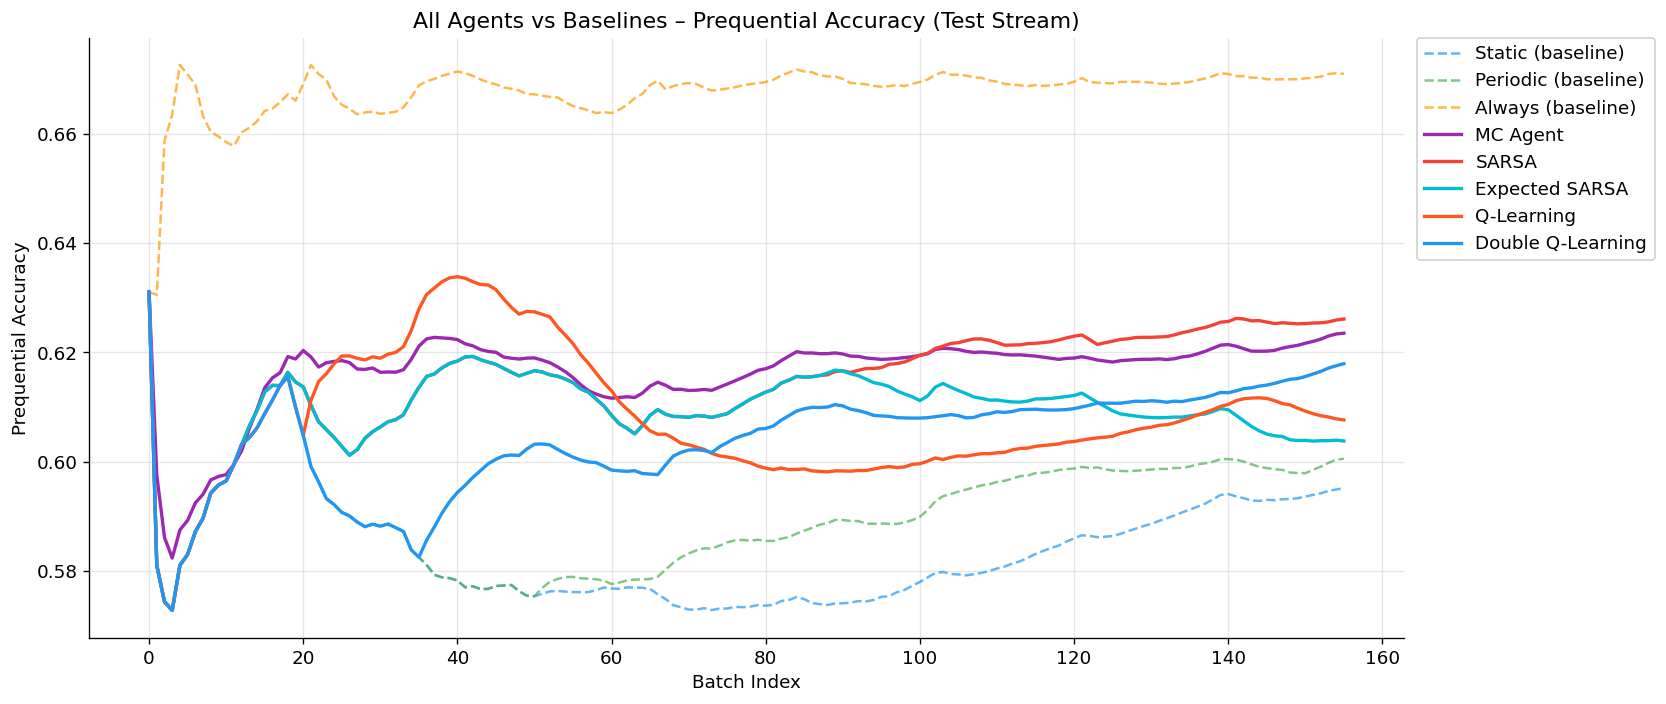

In [11]:
plot_agent_vs_baselines(
    baselines = {
        'Static'  : results_static['prequential_acc'],
        'Periodic': results_periodic['prequential_acc'],
        'Always'  : results_always['prequential_acc'],
    },
    agents = {
        'MC Agent'         : results_mc['prequential_acc'],
        'SARSA'            : results_sarsa['prequential_acc'],
        'Expected SARSA'   : results_exp['prequential_acc'],
        'Q-Learning'       : results_ql['prequential_acc'],
        'Double Q-Learning': results_dql['prequential_acc'],
    },
    ylabel   = 'Prequential Accuracy',
    title    = 'All Agents vs Baselines – Prequential Accuracy (Test Stream)',
    filename = 'all_agents_preq_acc.png',
)

## 11. Rolling Error Rate

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/all_agents_rolling_err.png


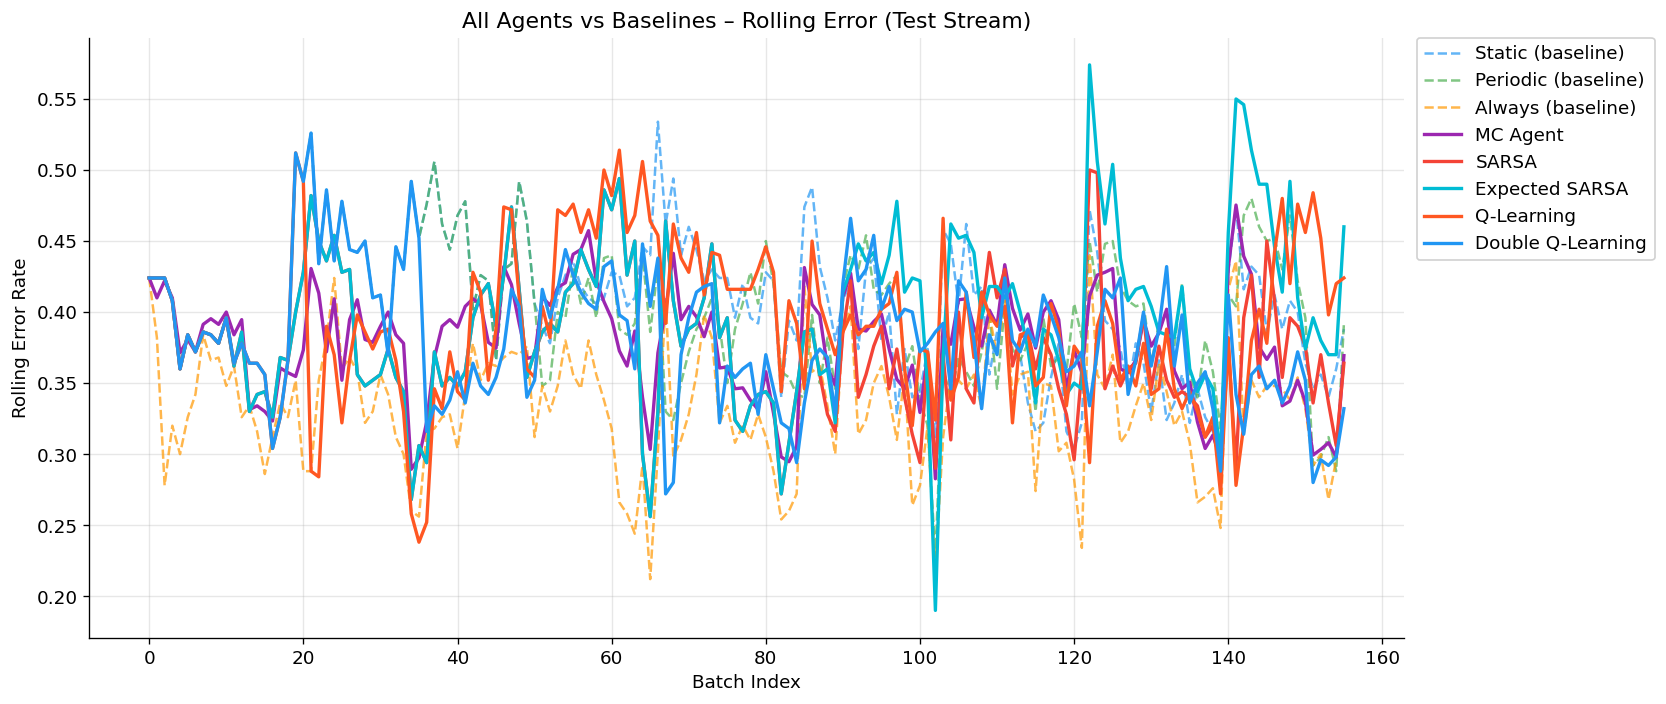

In [12]:
plot_agent_vs_baselines(
    baselines = {
        'Static'  : results_static['rolling_error'],
        'Periodic': results_periodic['rolling_error'],
        'Always'  : results_always['rolling_error'],
    },
    agents = {
        'MC Agent'         : results_mc['rolling_error'],
        'SARSA'            : results_sarsa['rolling_error'],
        'Expected SARSA'   : results_exp['rolling_error'],
        'Q-Learning'       : results_ql['rolling_error'],
        'Double Q-Learning': results_dql['rolling_error'],
    },
    ylabel   = 'Rolling Error Rate',
    title    = 'All Agents vs Baselines – Rolling Error (Test Stream)',
    filename = 'all_agents_rolling_err.png',
)

## 12. Action Distribution – Agents

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/all_agents_action_dist.png


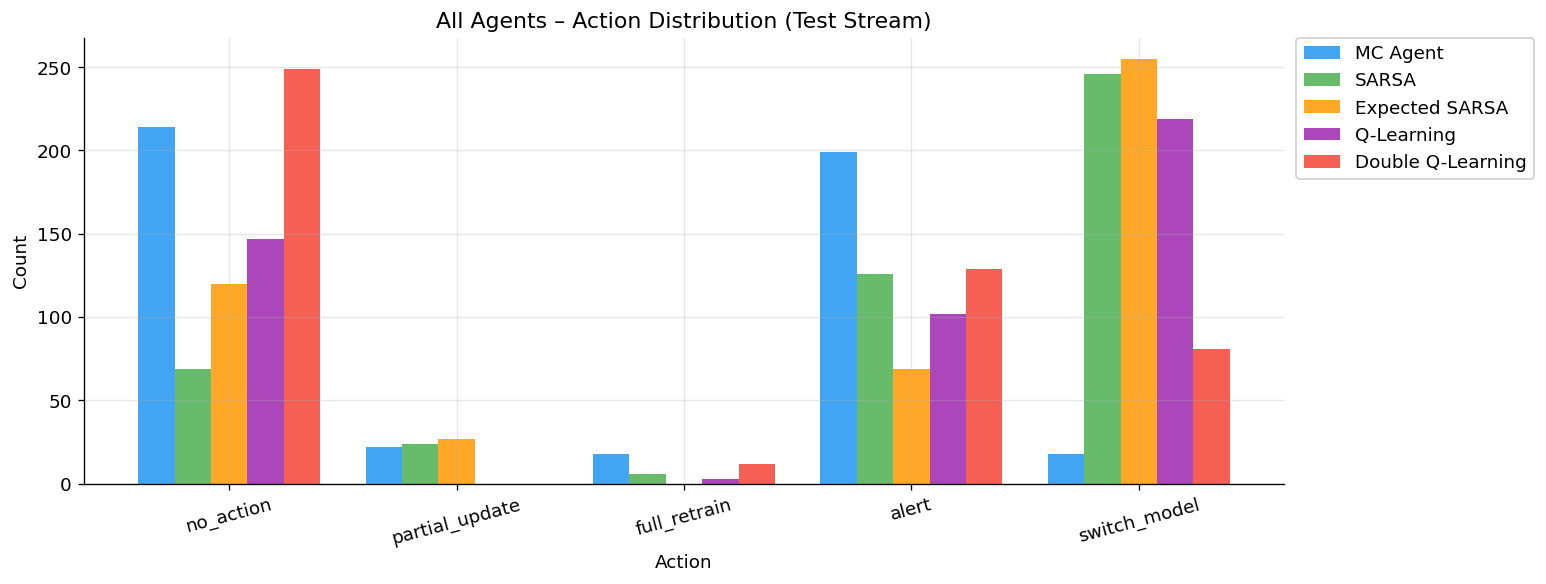


Action distribution (%):

  MC Agent:
    no_action       :  45.4%
    alert           :  42.3%
    partial_update  :   4.7%
    switch_model    :   3.8%
    full_retrain    :   3.8%

  SARSA:
    switch_model    :  52.2%
    alert           :  26.8%
    no_action       :  14.6%
    partial_update  :   5.1%
    full_retrain    :   1.3%

  Expected SARSA:
    switch_model    :  54.1%
    no_action       :  25.5%
    alert           :  14.6%
    partial_update  :   5.7%

  Q-Learning:
    switch_model    :  46.5%
    no_action       :  31.2%
    alert           :  21.7%
    full_retrain    :   0.6%

  Double Q-Learning:
    no_action       :  52.9%
    alert           :  27.4%
    switch_model    :  17.2%
    full_retrain    :   2.5%


In [13]:
plot_action_distribution(
    {
        'MC Agent'         : results_mc['action_dist'],
        'SARSA'            : results_sarsa['action_dist'],
        'Expected SARSA'   : results_exp['action_dist'],
        'Q-Learning'       : results_ql['action_dist'],
        'Double Q-Learning': results_dql['action_dist'],
    },
    title    = 'All Agents – Action Distribution (Test Stream)',
    filename = 'all_agents_action_dist.png',
)

print('\nAction distribution (%):')
for name in ['MC Agent', 'SARSA', 'Expected SARSA', 'Q-Learning', 'Double Q-Learning']:
    r = all_results[name]
    print(f'\n  {name}:')
    for action, pct in sorted(r['action_dist_pct'].items(), key=lambda x: -x[1]):
        print(f'    {action:<16}: {pct:>5.1f}%')

## 13. Retrain Events per Agent

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/mc_agent_retrain.png


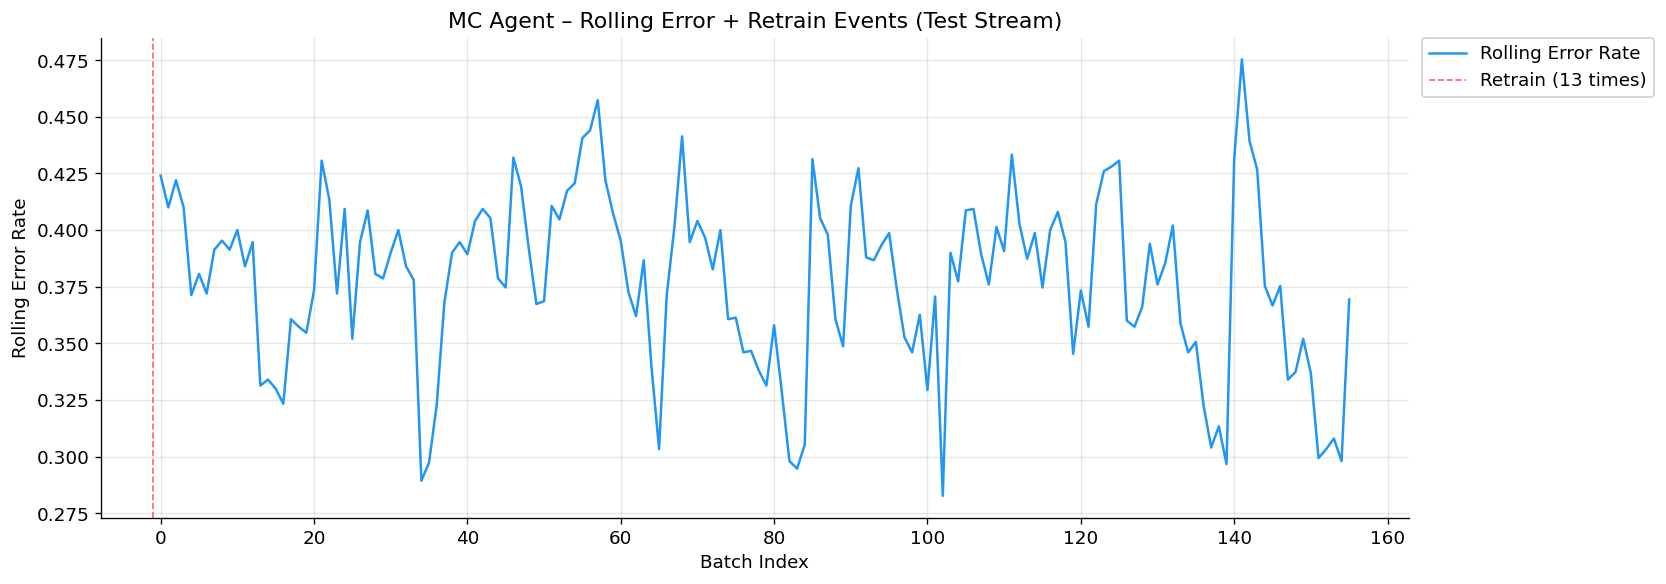

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/sarsa_retrain.png


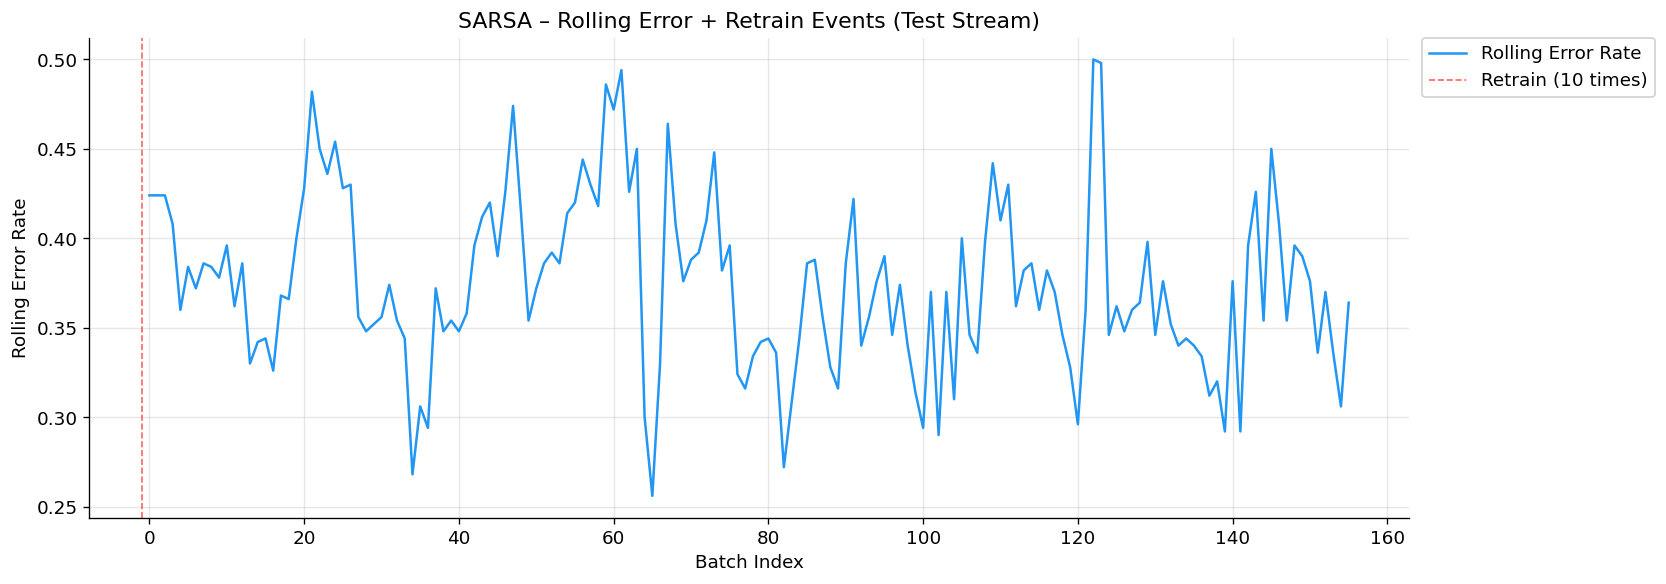

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/expected_sarsa_retrain.png


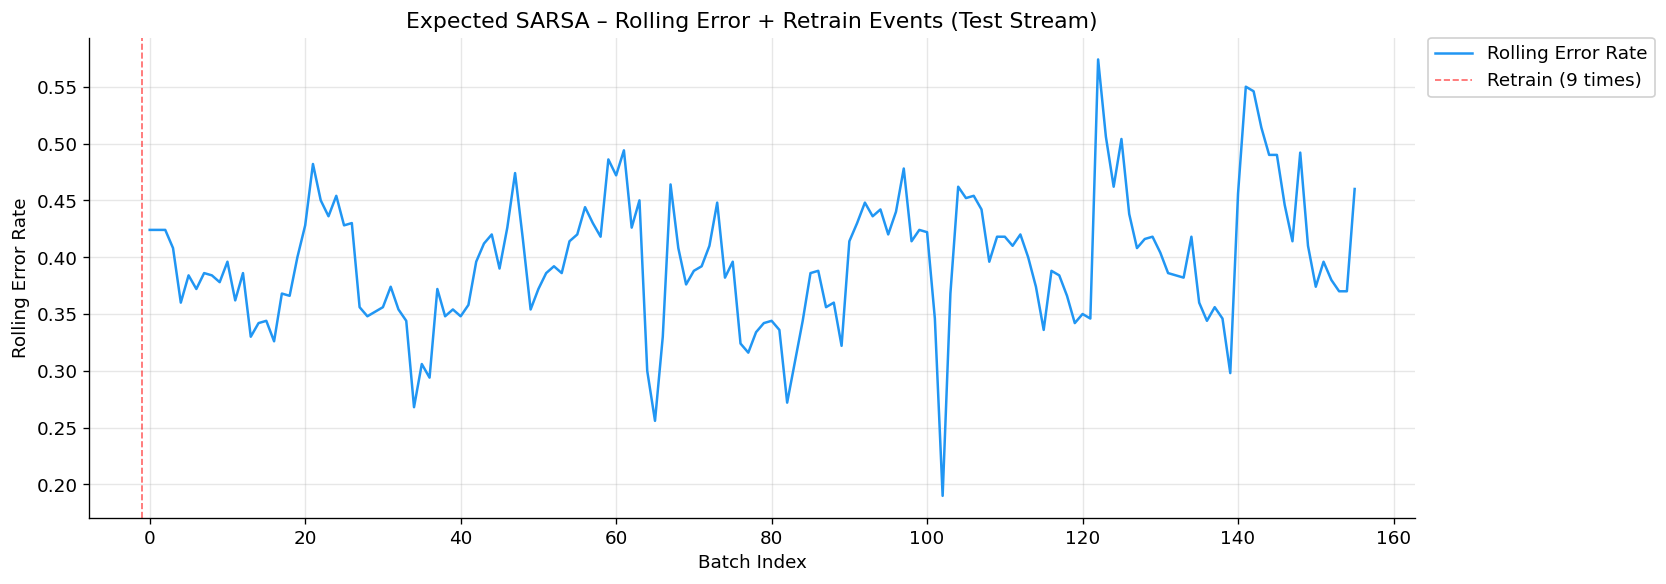

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/q_learning_retrain.png


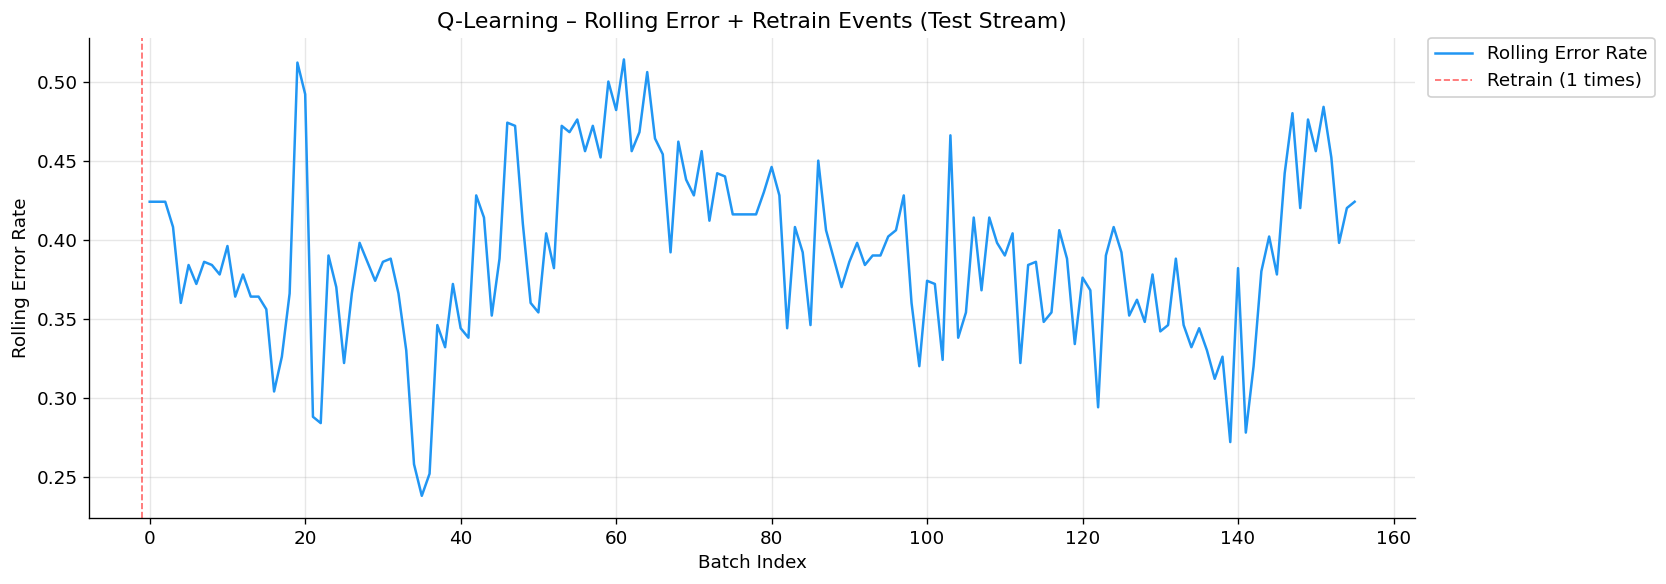

[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/double_q_learning_retrain.png


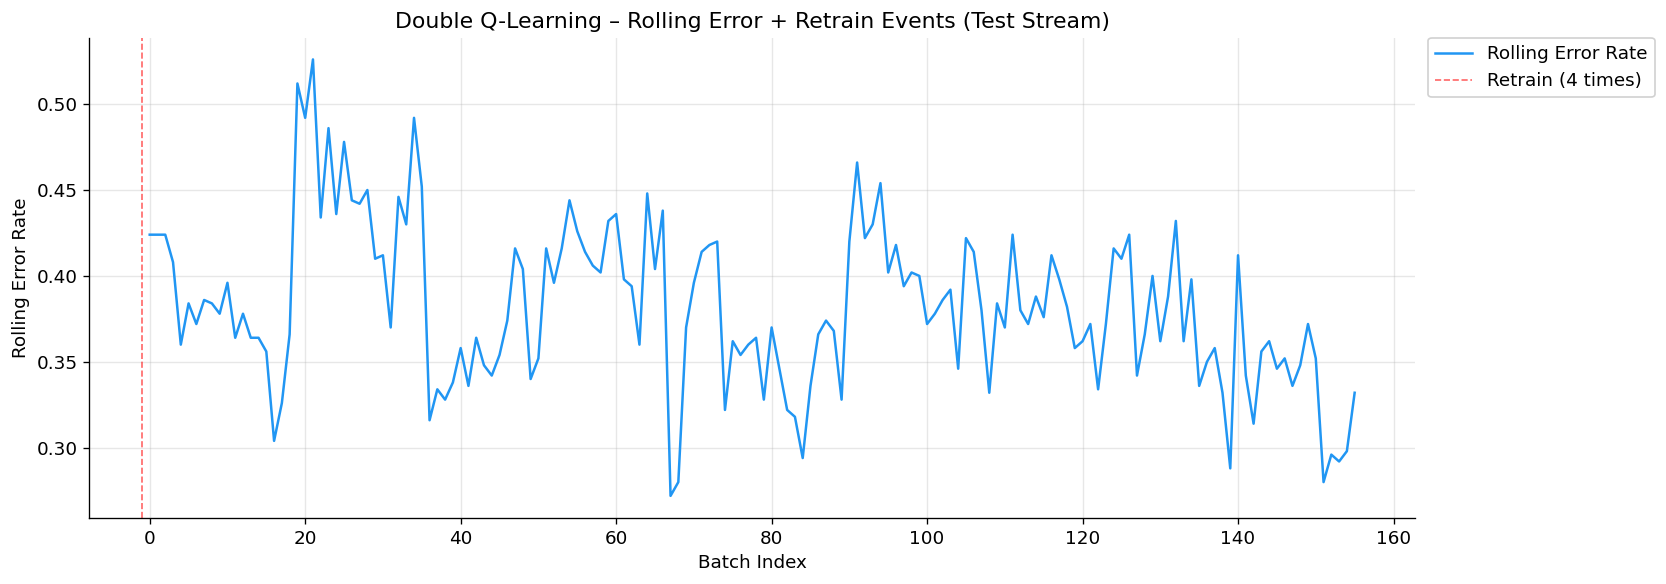

In [14]:
for name in ['MC Agent', 'SARSA', 'Expected SARSA', 'Q-Learning', 'Double Q-Learning']:
    r    = all_results[name]
    fname = name.lower().replace(' ', '_').replace('-', '_') + '_retrain.png'
    plot_retrain_events(
        r['rolling_error'],
        r['retrain_events'],
        title    = f'{name} – Rolling Error + Retrain Events (Test Stream)',
        filename = fname,
    )

## 14. Observations & Next Steps

**Câu hỏi cần trả lời:**

*Performance:*
- Agent nào có prequential accuracy cao nhất trên test stream?
- TD agents có vượt được MC Agent sau khi train đủ episodes không?
- SARSA (on-policy) vs Q-Learning (off-policy) – cái nào phù hợp hơn với non-stationary env?

*Retrain behavior:*
- Agent nào retrain nhiều nhất? Ít nhất?
- Double Q-Learning có ổn định hơn Q-Learning không (variance reward thấp hơn)?
- Expected SARSA có giảm variance so với SARSA không?

*So sánh với Always baseline:*
- Always retrain mọi batch → accuracy cao nhưng chi phí lớn
- Agent nào đạt được accuracy gần Always với số lần retrain ít hơn nhiều?

→ Nếu TD vẫn tệ hơn MC: thử tăng `N_TRAIN_EPISODES` lên 1000-2000  
→ Nếu Double Q-Learning tệ nhất: maximization bias không phải vấn đề lớn ở đây  
→ Nếu Q-Learning > SARSA: off-policy phù hợp hơn vì exploration steps không ảnh hưởng target
